<a href="https://colab.research.google.com/github/annkupina/ml_course_hw/blob/main/Anna_Kupina_HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_df = pd.read_csv('train.csv')

In [5]:
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [6]:
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=35, stratify= train_df['Exited'])
# використовую параметр stratify, який відповідає за збереження пропорції класів для тренувальної і валідаційної вибірок

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
input_cols = list(train_df.columns)[3:-1] #не додаю сюди колонки id, CustomerId, Surname, бо це просто різні ідентифікатори клієнтів
target_col = 'Exited'

train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [8]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [9]:
# дивлюсь чи є пропущені значення в якихось колонках
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 506 to 5988
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11250 non-null  int64  
 1   CustomerId       11250 non-null  float64
 2   Surname          11250 non-null  object 
 3   CreditScore      11250 non-null  float64
 4   Geography        11250 non-null  object 
 5   Gender           11250 non-null  object 
 6   Age              11250 non-null  float64
 7   Tenure           11250 non-null  float64
 8   Balance          11250 non-null  float64
 9   NumOfProducts    11250 non-null  float64
 10  HasCrCard        11250 non-null  float64
 11  IsActiveMember   11250 non-null  float64
 12  EstimatedSalary  11250 non-null  float64
 13  Exited           11250 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.3+ MB


In [10]:
# масштабую числові ознаки
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [11]:
# дивлюсь кількість унікальних категорій в категоріальних колонках
train_inputs[categorical_cols].nunique()

,0
Geography,3
Gender,2


In [12]:
# виконую кодування категоріальних ознак
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [13]:
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
506,0.630072,France,Male,0.196429,0.5,0.0,0.333333,1.0,0.0,0.251809,1.0,0.0,0.0,0.0,1.0
8370,0.639618,France,Male,0.375000,0.3,0.0,0.000000,1.0,0.0,0.855131,1.0,0.0,0.0,0.0,1.0
11168,0.479714,France,Female,0.339286,0.7,0.0,0.333333,1.0,1.0,0.472090,1.0,0.0,0.0,1.0,0.0
33,0.470167,France,Female,0.571429,0.2,0.0,0.666667,1.0,0.0,0.533990,1.0,0.0,0.0,1.0,0.0
11141,0.720764,France,Female,0.232143,0.5,0.0,0.333333,1.0,1.0,0.863117,1.0,0.0,0.0,1.0,0.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
13610,0.553699,France,Female,0.303571,1.0,0.0,0.333333,1.0,0.0,0.313705,1.0,0.0,0.0,1.0,0.0
3806,0.653938,France,Female,0.285714,0.2,0.0,0.333333,0.0,0.0,0.548707,1.0,0.0,0.0,1.0,0.0
632,0.553699,France,Male,0.303571,0.8,0.0,0.333333,1.0,0.0,0.709370,1.0,0.0,0.0,0.0,1.0
4278,0.305489,France,Male,0.446429,0.1,0.0,0.333333,1.0,1.0,0.193933,1.0,0.0,0.0,0.0,1.0
7286,0.536993,France,Male,0.553571,0.3,0.0,0.000000,1.0,0.0,0.698572,1.0,0.0,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [14]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [15]:
!ls

sample_data	       test.csv   train_inputs.parquet	 val_inputs.parquet
sample_submission.csv  train.csv  train_targets.parquet  val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import joblib

X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)


LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [17]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

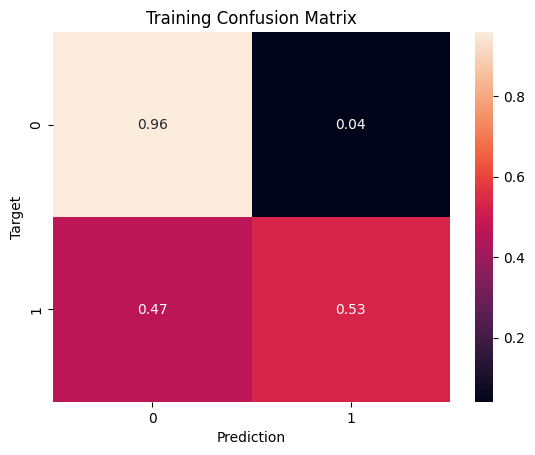

In [18]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

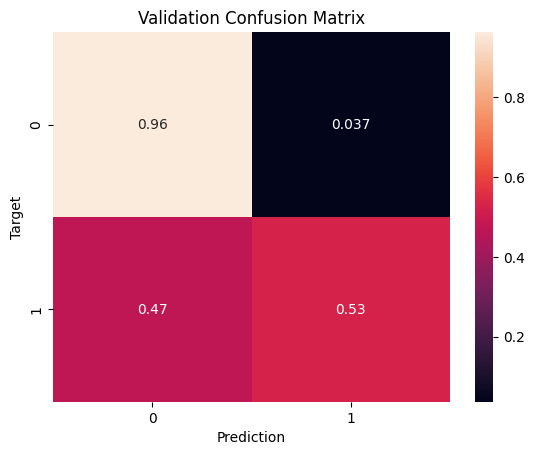

In [19]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [20]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.63%
F1 score Validation: 0.63%


In [21]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


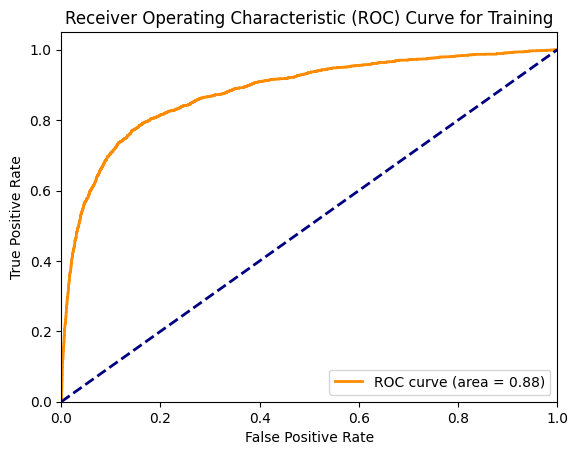

AUROC for Validation: 0.88


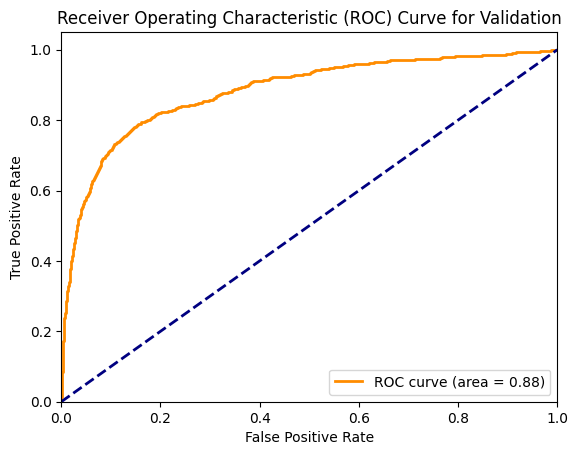

In [22]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

Я би сказала, що модель задовільна, бо AUROC = 0.88 - досить висока, F1 = 0.63%, що є більш менш задовільним показником. Дивлячись на наші сonfusion matrix, модель добре розрізняє клиєнтів класу 0, але клієнтів класу 1 розпізнає тільки 53% вірно, і 47% помилково відносить до класу 0. Хотілося б зробити модель тут точніше.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [23]:
majority_class = train_targets.mode()[0]
baseline_preds_train = np.full(shape=len(train_targets), fill_value=majority_class)
baseline_preds_val = np.full(shape=len(val_targets), fill_value=majority_class)

In [24]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [25]:
from sklearn.metrics import accuracy_score

baseline_acc_train = accuracy_score(train_targets, baseline_preds_train)
baseline_acc_val = accuracy_score(val_targets, baseline_preds_val)

model_acc_train = accuracy_score(train_targets, train_preds)
model_acc_val = accuracy_score(val_targets, val_preds)

print(f"Baseline Accuracy Training: {baseline_acc_train:.2f}")
print(f"Baseline Accuracy Validation: {baseline_acc_val:.2f}")
print(f"Model Accuracy Training: {model_acc_train:.2f}")
print(f"Model Accuracy Validation: {model_acc_val:.2f}")

Baseline Accuracy Training: 0.80
Baseline Accuracy Validation: 0.80
Model Accuracy Training: 0.87
Model Accuracy Validation: 0.87


Модель задовільна. Стабільність в метриках тренувальної і валідаційної вибірок показує, що модель добре навчилась. Model Accuracy Training/Validation: 0.87 вище ніж у baseline, але не суттєво. До цього те, що я писала вище, що F1 score: 0.63% і сonfusion matrix хотілося б покращити.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [26]:
import joblib

log_reg = {'model': model, 'scaler': scaler, 'encoder': encoder,
               'input_cols': input_cols, 'target_col': target_col, 'numeric_cols': numeric_cols,
               'categorical_cols': categorical_cols, 'encoded_cols': encoded_cols}
joblib.dump(log_reg, 'log_reg.joblib')
model_2 = joblib.load('log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [27]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:, 1]
    return prob

In [28]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, train_inputs)

array([0.01164852, 0.01845468, 0.00710563, ..., 0.04531527, 0.08220133,
       0.03890489])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [29]:
test_raw_df = pd.read_csv('test.csv')

test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [30]:
sample_submission = pd.read_csv('sample_submission.csv')

sample_submission['Exited'] = test_raw_df['Exited'].values

sample_submission.to_csv('submission_log_reg.csv', index=False)

In [31]:
sample_submission.head()

,id,Exited
0,15000,0.076387
1,15001,0.032992
2,15002,0.153552
3,15003,0.185095
4,15004,0.052904
